In [ ]:
# From MuJoCo tutorial

!pip install mujoco

from google.colab import files
import distutils.util
import os

NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
      'file_format_version': '1.0.0',
      'ICD':{
        'library_path': 'libEGL_nvidia.so.0'
      }
      }
    }""")

print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco
  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError('Something went wrong')

print('Installation successful.')

import time
import itertools
import numpy as np


print('Installing mediapy:')
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True, linewidth=100)

from IPython.display import clear_output
clear_output()

In [ ]:
!pip install mujoco.mjx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 51.2 MB/s eta 0:00:00


In [ ]:
import mujoco.mjx as mjx
import jax
import jax.numpy as jnp

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


current theta: 0.0


""

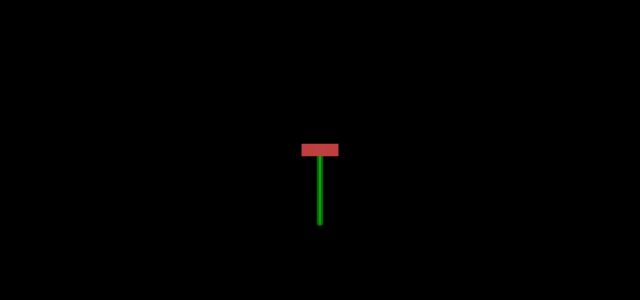

In [ ]:
cartpole_xml = """
<mujoco model="cartpole">
  <option timestep="0.005"/>
  <worldbody>
    <camera name="side" pos="0 -3 0" xyaxes="1 0 0 0 0 1"/>
    <body name="cart">
      <joint name="slider" type="slide" axis="1 0 0" range="-2 2"/>
      <geom type="box" size="0.15 0.05 0.05" rgba="1 0 0 1" mass="1.0"/>
      <body name="pole">
        <joint name="hinge" type="hinge" axis="0 1 0"/>
        <geom type="capsule" fromto="0 0 0 0 0 -0.6" size="0.03" rgba="0 1 0 1" mass="0.01"/>
      </body>
    </body>
  </worldbody>

  <actuator>
    <motor joint="slider" ctrllimited="true" ctrlrange="-100 100"/>
  </actuator>
</mujoco>
"""

model = mujoco.MjModel.from_xml_string(cartpole_xml)
data = mujoco.MjData(model)
data.qpos[1] = 0

dt = 0.02

print('current theta:', data.qpos[1])
with mujoco.Renderer(model, 300, 640) as renderer:
  mujoco.mj_forward(model, data)

  renderer.update_scene(data, camera='side')

  media.show_image(renderer.render())


In [ ]:
model = mujoco.MjModel.from_xml_string(cartpole_xml)
data = mujoco.MjData(model)
dt = 0.02

# MJX model for GPU rollout
mjx_model = mjx.put_model(model)


# One MPPI Rollout
def rollout(x0, u_seq, key, sigma):
    N = u_seq.shape[0]

    # Sample noise and add to control sequence
    noise = sigma * jax.random.normal(key, (N, 1))
    u_noisy = u_seq + noise

    def step_fn(d, u):
        # Apply control
        u_clipped = jnp.clip(u[0], -100.0, 100.0)
        d = d.replace(ctrl=d.ctrl.at[0].set(u_clipped))
        d = mjx.step(mjx_model, d)

        # Extract state
        p = d.qpos[0]
        theta = d.qpos[1]
        theta = jnp.arctan2(jnp.sin(theta), jnp.cos(theta))
        p_dot = d.qvel[0]
        theta_dot = d.qvel[1]

        cost = (
            p**2 +
            500*(1 + jnp.cos(theta))**2 +
            p_dot**2 +
            theta_dot**2
        )
        return d, cost

    d0 = mjx.make_data(mjx_model)
    d0 = d0.replace(
        qpos=d0.qpos.at[0].set(x0[0]).at[1].set(x0[2]),
        qvel=d0.qvel.at[0].set(x0[1]).at[1].set(x0[3]),
    )
    d0 = mjx.kinematics(mjx_model, d0)

    # Rollout over horizon
    d_final, costs = jax.lax.scan(step_fn, d0, u_noisy)

    # Terminal cost
    theta_T = jnp.arctan2(jnp.sin(d_final.qpos[1]), jnp.cos(d_final.qpos[1]))
    terminal_cost = 10.0 * theta_T**2

    total_cost = jnp.sum(costs) + terminal_cost
    return total_cost, noise


@jax.jit
def mppi_update(x0, u_seq, key, sigma, lam):
    K = 1000
    keys = jax.random.split(key, K)

    costs, noises = jax.vmap(rollout, in_axes=(None, None, 0, None))(x0, u_seq, keys, sigma)

    # calculate weights
    beta = jnp.min(costs)
    w = jnp.exp(-(costs - beta) / lam)
    w = w / (jnp.sum(w) + 1e-8)

    # Control update
    du = jnp.sum(w[:, None, None] * noises, axis=0)
    new_u_seq = u_seq + du

    new_u_seq = new_u_seq.at[:-1].set(new_u_seq[1:])
    new_u_seq = new_u_seq.at[-1].set(0.0)

    key, new_key = jax.random.split(key)
    return new_u_seq, new_key


class JAXMPPIController:
    def __init__(self, horizon=100):
        self.u_seq = jnp.zeros((horizon, 1))
        self.key = jax.random.PRNGKey(0)

    def command(self, data, sigma):
        # x0 = [p, p_dot, theta, theta_dot]
        x0 = jnp.array([
            float(data.qpos[0]),
            float(data.qvel[0]),
            float(data.qpos[1]),
            float(data.qvel[1]),
        ])

        self.u_seq, self.key = mppi_update(
            x0,
            self.u_seq,
            self.key,
            sigma=sigma,
            lam=50.0,
        )

        return float(self.u_seq[0, 0])


# Simulation loop
data.qpos[1] = 0  # start downward
controller = JAXMPPIController(horizon=100)

T = 20.0 # Test with 20s to check the stability maintain ability.
steps = int(T / dt)
frames = []

with mujoco.Renderer(model, 300, 640) as renderer:
    for t in range(steps):
        theta = data.qpos[1]
        theta = (theta + np.pi) % (2 * np.pi) - np.pi

        sigma = 50.0

        u = controller.command(data, sigma)
        data.ctrl[0] = float(np.clip(u, -100.0, 100.0))

        mujoco.mj_step(model, data)

        renderer.update_scene(data, camera='side')
        frames.append(renderer.render())

media.show_video(frames, fps=50)

This browser does not support the video tag.


In [ ]:
media.show_video(frames, fps=40)

This browser does not support the video tag.
